# Problem Statment
Develop a machine learning model to detect potentially fraudulent transactions based on the provided features. The dataset contains information about various transactions, including account age, payment method, time of transaction, and category. The goal is to build a classification model that can accurately classify transactions as either legitimate or potentially fraudulent.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Dictionary
1. <b>accountAgeDays:</b> The number of days the account has been active.
2. <b>numItems:</b> The number of items associated with the account.
3. <b>localTime:</b> Some measure of time, possibly in hours or a similar unit.
4. <b>paymentMethod:</b> The method used for payment (e.g., PayPal, store credit, credit card).
5. <b>paymentMethodAgeDays:</b> The number of days since the payment method was associated with the account.(It indicates how long ago the current payment method (e.g., PayPal, credit card) was linked to the account.)
6. <b>isWeekend:</b> A binary indicator of whether the transaction occurred on a weekend (1 for yes, 0 for no).
7. <b>Category:</b> The category of the transaction (e.g., electronics, shopping, food).
8. <b>Label</b>(Target column) A binary label (0 for legitimate, 1 for potentially fraudulent).ent).ulent).

In [2]:
#import libraries
import numpy as np #array and math calculation
import pandas as pd #data manipulation
import matplotlib.pyplot as plt #visualization lib
import seaborn as sns #advance visualization lib
#plot graph directly below the code cell
%matplotlib inline
sns.set(style="darkgrid", palette="viridis") #set style current session

#import libraries for model build
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, recall_score, precision_score, roc_auc_score, roc_curve, accuracy_score, f1_score

#ignore harmless warnings
import warnings
warnings.filterwarnings('ignore')


In [3]:
#import data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/project4/payment_fraud.csv')

#data dimension
df.shape

(39221, 8)

In [4]:
#sample data
df.head()

,accountAgeDays,numItems,localTime,paymentMethod,paymentMethodAgeDays,Category,isWeekend,label
0,29,1,4.745402,paypal,28.204861,shopping,0.0,0
1,725,1,4.742303,storecredit,0.000000,electronics,0.0,0
2,845,1,4.921318,creditcard,0.000000,food,1.0,0
3,503,1,4.886641,creditcard,0.000000,electronics,1.0,0
4,2000,1,5.040929,creditcard,0.000000,shopping,0.0,0


## Data preprossesing and cleaning

In [5]:
#check for duplicate data
print(f'Data has {df.duplicated().sum()} duplicate data')

Data has 3033 duplicate data


In [6]:
#remove duplicated data
df.drop_duplicates(inplace=True,ignore_index=True)

#sample data after droping duplicate
print(df.shape)
df.head()

(36188, 8)


,accountAgeDays,numItems,localTime,paymentMethod,paymentMethodAgeDays,Category,isWeekend,label
0,29,1,4.745402,paypal,28.204861,shopping,0.0,0
1,725,1,4.742303,storecredit,0.000000,electronics,0.0,0
2,845,1,4.921318,creditcard,0.000000,food,1.0,0
3,503,1,4.886641,creditcard,0.000000,electronics,1.0,0
4,2000,1,5.040929,creditcard,0.000000,shopping,0.0,0


In [7]:
#check for datatype
print(pd.concat([df.dtypes,df.head(3).T],axis=1))

                            0          0            1           2
accountAgeDays          int64         29          725         845
numItems                int64          1            1           1
localTime             float64   4.745402     4.742303    4.921318
paymentMethod          object     paypal  storecredit  creditcard
paymentMethodAgeDays  float64  28.204861          0.0         0.0
Category               object   shopping  electronics        food
isWeekend             float64        0.0          0.0         1.0
label                   int64          0            0           0


### Observation:
All features have valid datatypes

In [8]:
#check for null values
df.isnull().sum()

,0
accountAgeDays,0
numItems,0
localTime,0
paymentMethod,0
paymentMethodAgeDays,0
Category,95
isWeekend,396
label,0


In [9]:
print(df['Category'].value_counts())
print()
print(df['isWeekend'].value_counts())

Category
shopping       12339
food           11945
electronics    11809
Name: count, dtype: int64

isWeekend
0.0    17907
1.0    17885
Name: count, dtype: int64


In [10]:
#impute mode for Category and isWeekend feature
df['Category'].fillna(df['Category'].mode()[0],inplace=True)
df['isWeekend'].fillna(df['isWeekend'].mode()[0],inplace=True)

In [11]:
#check after null imputation
print(df['Category'].value_counts())
print()
print(df['isWeekend'].value_counts())
print()
df.isnull().sum()

Category
shopping       12434
food           11945
electronics    11809
Name: count, dtype: int64

isWeekend
0.0    18303
1.0    17885
Name: count, dtype: int64



,0
accountAgeDays,0
numItems,0
localTime,0
paymentMethod,0
paymentMethodAgeDays,0
Category,0
isWeekend,0
label,0


## EDA (Exploratory Data Analysis)

<Axes: >

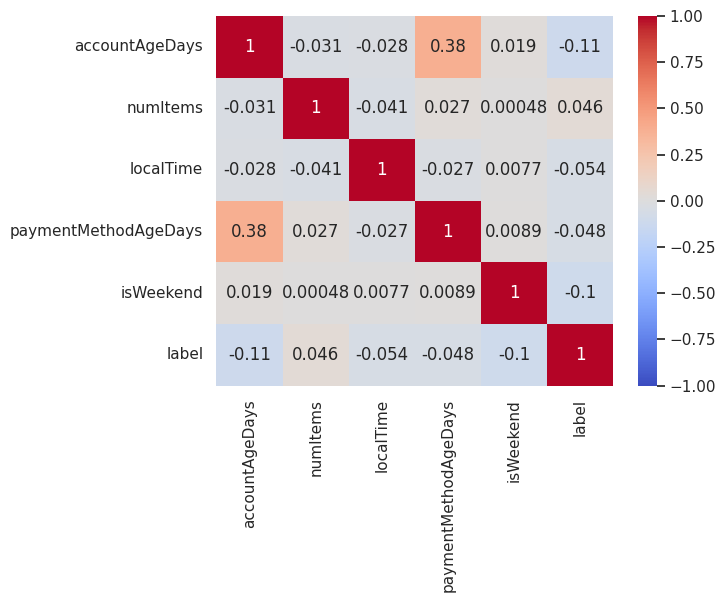

In [12]:
#chceck corelation
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)


In [13]:
# seperate categorical data and numerical data
num_cols = ['accountAgeDays','localTime','paymentMethodAgeDays']
cat_cols = ['numItems','paymentMethod','Category','isWeekend']
target_col = 'label'

In [14]:
# understand target column
df[target_col].value_counts(normalize=True)*100

,proportion
label,
0,98.905715
1,1.094285


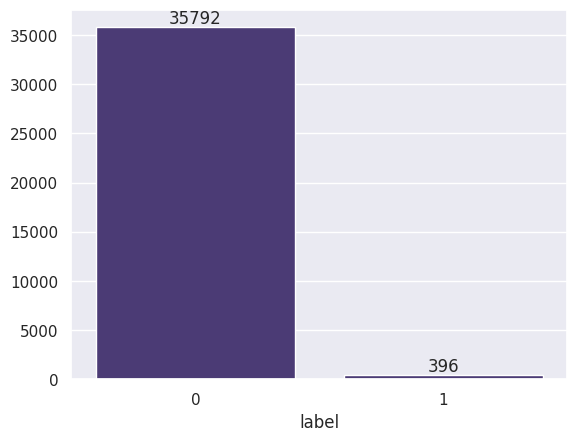

In [15]:
#plot bar graph for target variable

ax = sns.barplot(x=df['label'].value_counts().index,y=df['label'].value_counts().values)
ax.bar_label(ax.containers[0])
plt.show()

In [16]:
#understand numerical features

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
accountAgeDays,36188.0,813.805958,779.398060,1.000000,74.000000,550.000000,1639.000000,2000.000000
localTime,36188.0,4.741856,0.396812,0.421214,4.742303,4.886641,4.962055,5.040929
paymentMethodAgeDays,36188.0,132.808107,292.737789,0.000000,0.000000,0.154167,108.652431,1999.580556


In [17]:
#understand numerical features with respect to label

print('For legimitate trasactions:')
print(df[df['label']==0][num_cols].describe())

print('-----------------------------------------------------------')


print('For fraudulent trasactions:')
print(df[df['label']==1][num_cols].describe())

For legimitate trasactions:
       accountAgeDays     localTime  paymentMethodAgeDays
count    35792.000000  35792.000000          35792.000000
mean       822.798782      4.744127            134.277291
std        778.968505      0.392844            294.017532
min          2.000000      0.421214              0.000000
25%         80.000000      4.742303              0.000000
50%        569.000000      4.886641              0.268056
75%       1648.000000      4.962055            111.096007
max       2000.000000      5.040929           1999.580556
-----------------------------------------------------------
For fraudulent trasactions:
       accountAgeDays   localTime  paymentMethodAgeDays
count           396.0  396.000000            396.000000
mean              1.0    4.536572              0.017556
std               0.0    0.631704              0.097071
min               1.0    2.596228              0.000000
25%               1.0    4.505662              0.000000
50%               1.0    4

### Observation:
1. In accountAgeDays column, all fraudulent transactions had a value of 1,
while legitimate transactions had values greater than 1.
2. The accountAgeDays feature shows strong data leakage.
3. Retaining this column could lead to overfitting, as the model might rely too heavily on this feature to distinguish between fraud and non-fraud cases, resulting in unrealistic performance during training.


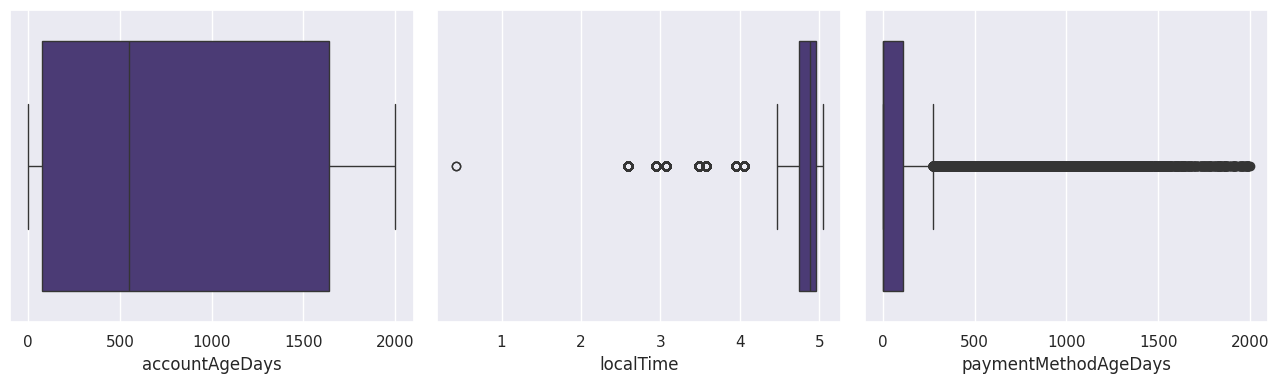

In [18]:
#plot box plot
c=1
plt.figure(figsize=(13,4))
for col in num_cols:
  plt.subplot(1,3,c)
  sns.boxplot(x=df[col])
  c +=1

plt.tight_layout()
plt.show()


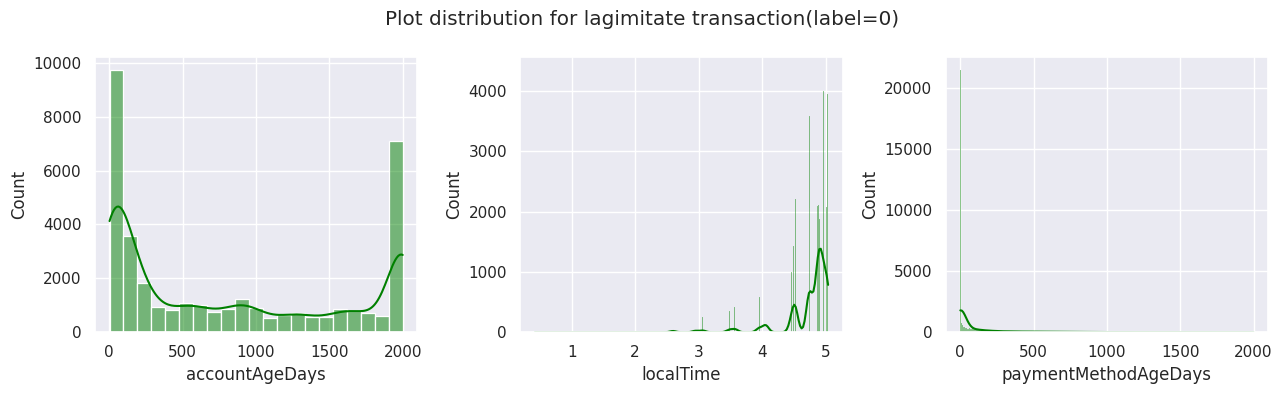

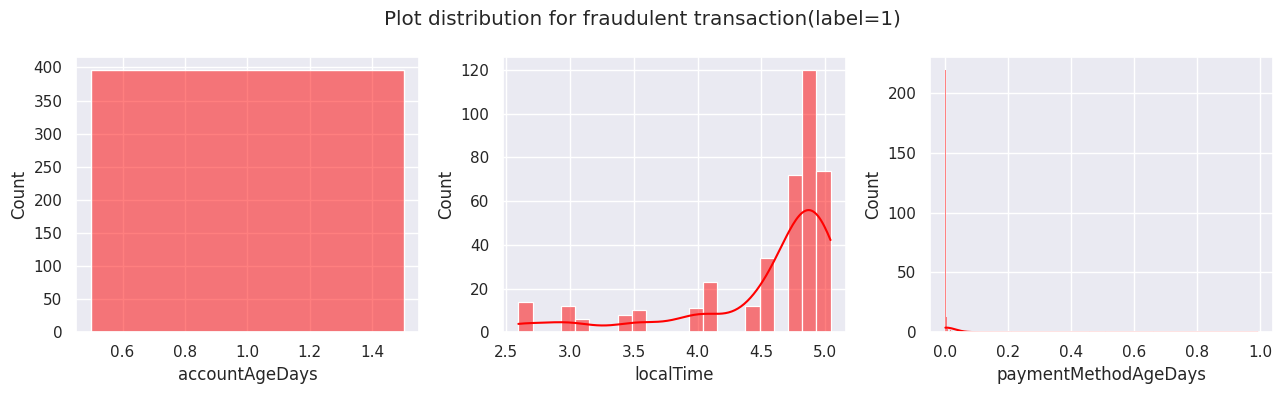

In [19]:

#plot histogram for label 0
c=1
plt.figure(figsize=(13,4))
for col in num_cols:
  plt.subplot(1,3,c)
  sns.histplot(x=df[df['label']==0][col],kde=True,color='green')
  # plt.ylabel('')
  # plt.yticks([])
  c +=1

plt.suptitle('Plot distribution for lagimitate transaction(label=0)')
plt.tight_layout()
plt.show()

#plot histogram for label 1
c=1
plt.figure(figsize=(13,4))
for col in num_cols:
  plt.subplot(1,3,c)
  sns.histplot(x=df[df['label']==1][col],kde=True,color='red')
  # plt.ylabel('')
  # plt.yticks([])
  c +=1

plt.suptitle('Plot distribution for fraudulent transaction(label=1)')
plt.tight_layout()
plt.show()

### Observation:
1. columns localTime and paymentMethodAgeDays have outliers
2. Insight for fradulent transactions:
  * Account has been active for only 1 days.
  * The current payment method was linked to the account less than a day.

In [20]:
#apply IQR(capping) methond to handle outliers

for col in num_cols:
  if col != 'accountAgeDays':
    Q1 = np.quantile(df[col],0.25)
    Q3 = np.quantile(df[col],0.75)
    IQR = Q3 - Q1
    LL = Q1 - 1.5*IQR
    UL = Q3 + 1.5*IQR
    df[col] = np.where(df[col]<LL,LL,np.where(df[col]>UL,UL,df[col]))

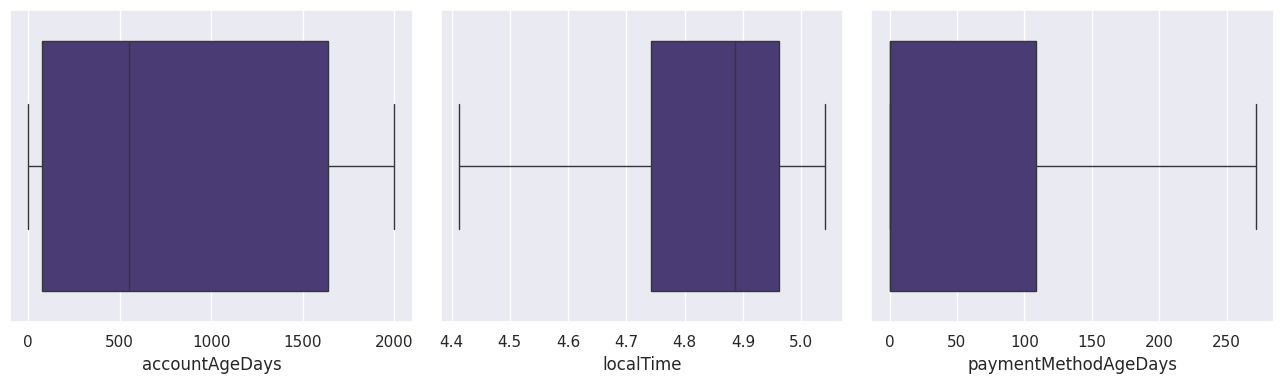

In [21]:
#plot box plot after outlier treatment
c=1
plt.figure(figsize=(13,4))
for col in num_cols:
  plt.subplot(1,3,c)
  sns.boxplot(x=df[col])
  c +=1

plt.tight_layout()
plt.show()


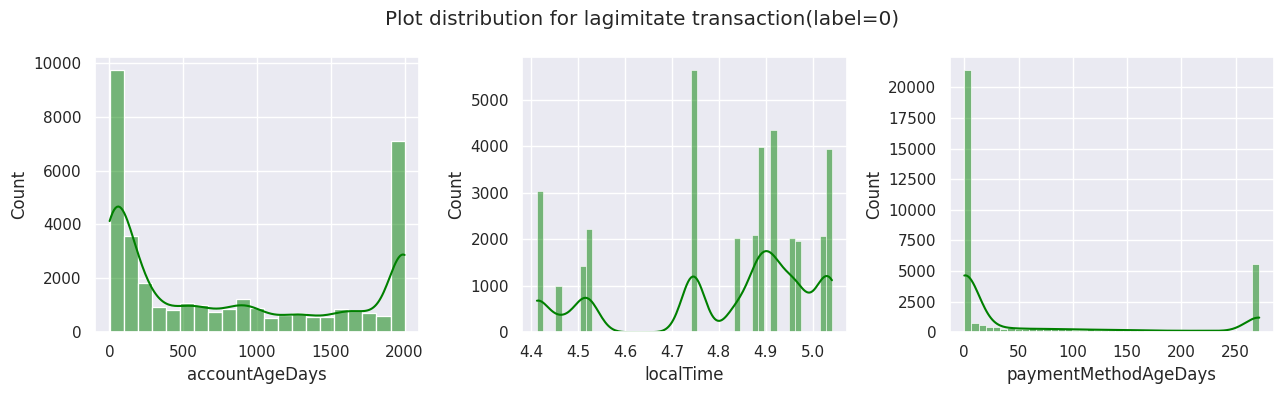

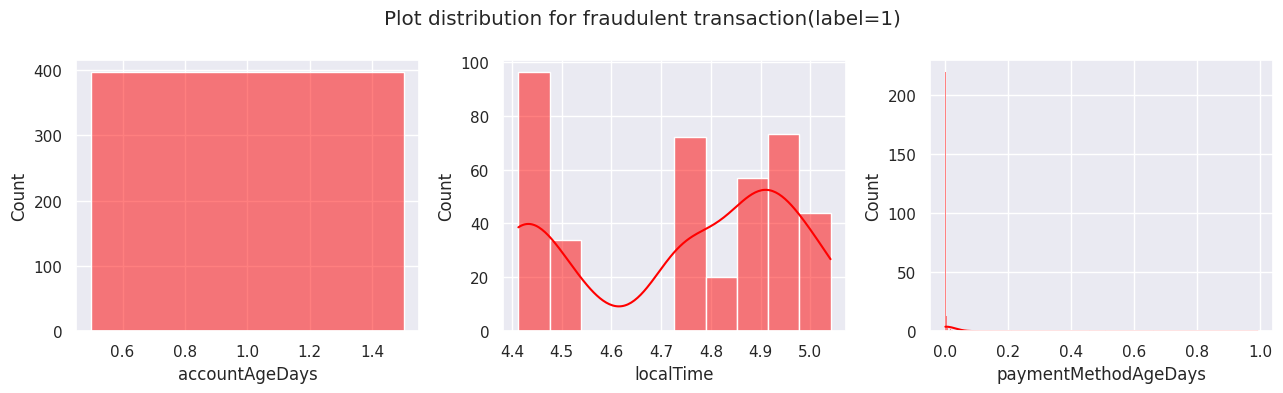

In [22]:

#plot histogram for label 0
c=1
plt.figure(figsize=(13,4))
for col in num_cols:
  plt.subplot(1,3,c)
  sns.histplot(x=df[df['label']==0][col],kde=True,color='green')
  # plt.ylabel('')
  # plt.yticks([])
  c +=1

plt.suptitle('Plot distribution for lagimitate transaction(label=0)')
plt.tight_layout()
plt.show()

#plot histogram for label 1
c=1
plt.figure(figsize=(13,4))
for col in num_cols:
  plt.subplot(1,3,c)
  sns.histplot(x=df[df['label']==1][col],kde=True,color='red')
  # plt.ylabel('')
  # plt.yticks([])
  c +=1

plt.suptitle('Plot distribution for fraudulent transaction(label=1)')
plt.tight_layout()
plt.show()

In [23]:
#understand categorical columns

for col in cat_cols:
  print('-------------------',col,'----------------------')
  print(df[col].value_counts())
  print()

------------------- numItems ----------------------
numItems
1     34381
2      1332
5       168
3       164
10       71
4        42
6        15
8         5
7         5
12        1
15        1
29        1
9         1
11        1
Name: count, dtype: int64

------------------- paymentMethod ----------------------
paymentMethod
creditcard     25545
paypal          8772
storecredit     1871
Name: count, dtype: int64

------------------- Category ----------------------
Category
shopping       12434
food           11945
electronics    11809
Name: count, dtype: int64

------------------- isWeekend ----------------------
isWeekend
0.0    18303
1.0    17885
Name: count, dtype: int64



In [24]:
#understand categorical features with respect to label

print('For legimitate trasactions:')
for col in cat_cols:
  print('-------------------',col,'----------------------')
  print(df[df['label']==0][col].value_counts())
  print()

print('************************************************')


print('For fraudulent trasactions:')
for col in cat_cols:
  print('-------------------',col,'----------------------')
  print(df[df['label']==1][col].value_counts())
  print()

For legimitate trasactions:
------------------- numItems ----------------------
numItems
1     34082
2      1259
5       164
3       148
10       70
4        39
6        15
8         5
7         5
12        1
15        1
29        1
9         1
11        1
Name: count, dtype: int64

------------------- paymentMethod ----------------------
paymentMethod
creditcard     25276
paypal          8666
storecredit     1850
Name: count, dtype: int64

------------------- Category ----------------------
Category
shopping       12292
food           11818
electronics    11682
Name: count, dtype: int64

------------------- isWeekend ----------------------
isWeekend
0.0    17907
1.0    17885
Name: count, dtype: int64

************************************************
For fraudulent trasactions:
------------------- numItems ----------------------
numItems
1     299
2      73
3      16
5       4
4       3
10      1
Name: count, dtype: int64

------------------- paymentMethod ----------------------
paymen

## Observation:
1. Fraudulent transaction are mostly done on weekdays.

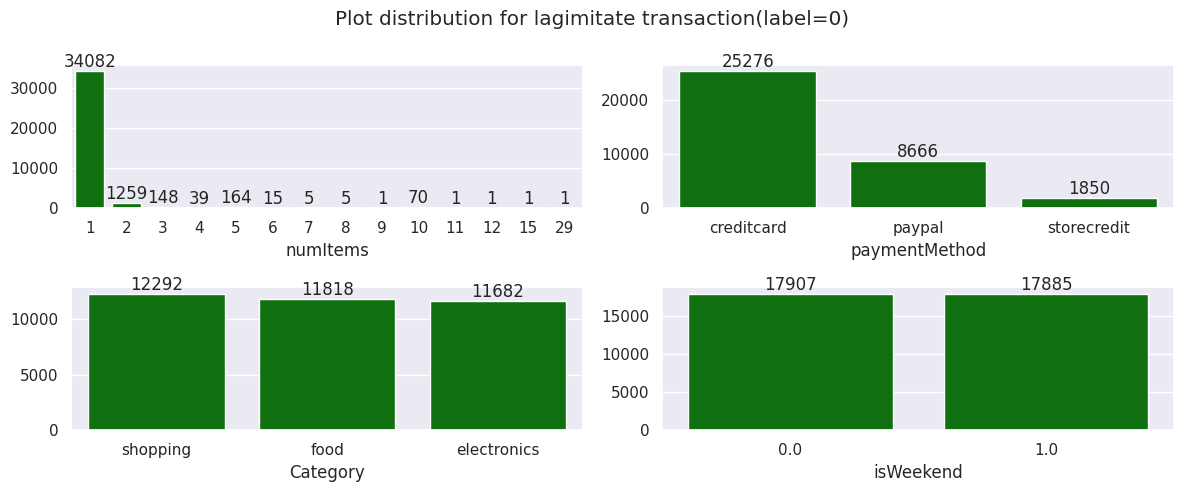

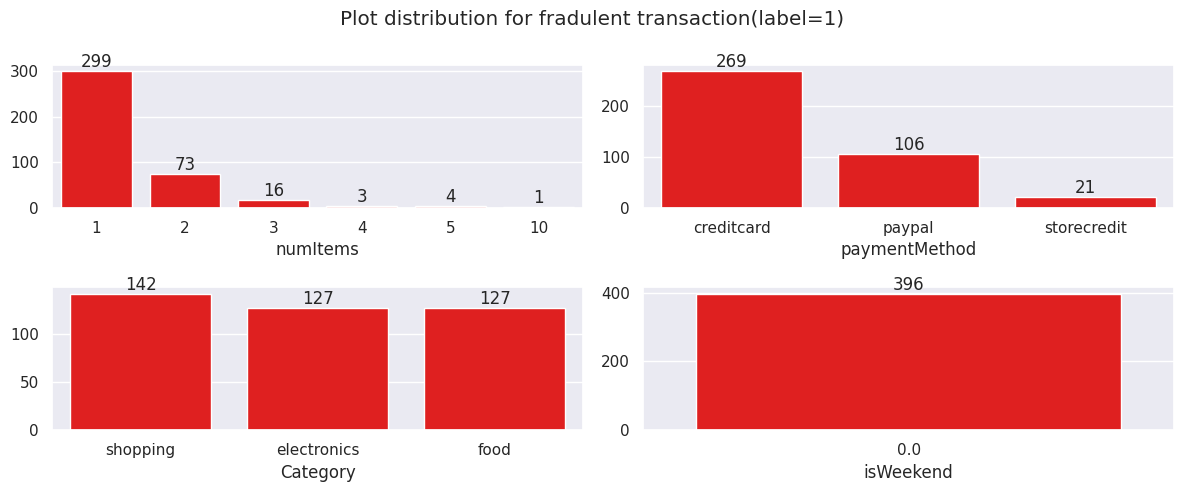

In [25]:
#plot bar chart
c=1
plt.figure(figsize=(12,5))
for col in cat_cols:
  plt.subplot(2,2,c)
  ax=sns.barplot(x=df[df['label']==0][col].value_counts().index,y=df[df['label']==0][col].value_counts().values,color='green')
  for container in ax.containers:
    ax.bar_label(container)
  c +=1

plt.suptitle('Plot distribution for lagimitate transaction(label=0)')
plt.tight_layout()
plt.show()


c=1
plt.figure(figsize=(12,5))
for col in cat_cols:
  plt.subplot(2,2,c)
  ax=sns.barplot(x=df[df['label']==1][col].value_counts().index,y=df[df['label']==1][col].value_counts().values,color='red')
  for container in ax.containers:
    ax.bar_label(container)
  c +=1

plt.suptitle('Plot distribution for fradulent transaction(label=1)')
plt.tight_layout()
plt.show()

## Model Building

In [26]:
# dependent and independent variable split
x = df.drop(['label','accountAgeDays'],axis=1)
y = df['label']

#train test split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

#train test dimensions
print('x_train',x_train.shape)
print('y_train',y_train.shape)
print('x_test',x_test.shape)
print('y_test',y_test.shape)

x_train (28950, 6)
y_train (28950,)
x_test (7238, 6)
y_test (7238,)


In [27]:
#encoding of categorical object features using OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, dtype='int', drop='first')
encoded_x_train = encoder.fit_transform(x_train[['paymentMethod','Category']])
encoded_x_train = pd.DataFrame(encoded_x_train,columns=encoder.get_feature_names_out(),index=x_train.index)
encoded_x_train

,paymentMethod_paypal,paymentMethod_storecredit,Category_food,Category_shopping
11127,0,0,1,0
31956,0,0,0,1
17521,1,0,0,1
3663,0,0,0,0
2563,0,0,1,0
...,...,...,...,...
3334,0,0,1,0
12742,1,0,1,0
35,0,0,0,0
24788,1,0,1,0


In [28]:
print(x_train.shape)
print(encoded_x_train.shape)
print(x_train)

(28950, 6)
(28950, 4)
       numItems  localTime paymentMethod  paymentMethodAgeDays     Category  \
11127         1   5.040929    creditcard            106.273611         food   
31956         1   4.895263    creditcard              0.022222     shopping   
17521         1   4.876771        paypal            134.110417     shopping   
3663          1   4.748314    creditcard             15.968750  electronics   
2563          1   5.017904    creditcard              0.000000         food   
...         ...        ...           ...                   ...          ...   
3334          1   4.412675    creditcard            271.631076         food   
12742         1   5.034622        paypal             61.956944         food   
35            1   5.017904    creditcard              0.000000  electronics   
24788         1   4.965339        paypal              0.000000         food   
29328         1   4.748314   storecredit              0.000000     shopping   

       isWeekend  
11127     

In [29]:
encoded_x_test = encoder.transform(x_test[['paymentMethod','Category']])
encoded_x_test = pd.DataFrame(encoded_x_test,columns=encoder.get_feature_names_out(),index=x_test.index)
encoded_x_test

,paymentMethod_paypal,paymentMethod_storecredit,Category_food,Category_shopping
9626,0,0,0,1
15267,0,0,0,1
10283,0,0,0,0
24262,0,0,0,1
31486,0,0,0,0
...,...,...,...,...
7627,1,0,1,0
10158,1,0,0,1
18358,0,0,0,0
18300,0,0,0,1


In [30]:
new_encoded_x_train = x_train.drop(['paymentMethod','Category'],axis=1)
new_encoded_x_train = pd.concat([new_encoded_x_train,encoded_x_train],axis=1)
new_encoded_x_train

,numItems,localTime,paymentMethodAgeDays,isWeekend,paymentMethod_paypal,paymentMethod_storecredit,Category_food,Category_shopping
11127,1,5.040929,106.273611,1.0,0,0,1,0
31956,1,4.895263,0.022222,0.0,0,0,0,1
17521,1,4.876771,134.110417,0.0,1,0,0,1
3663,1,4.748314,15.968750,1.0,0,0,0,0
2563,1,5.017904,0.000000,1.0,0,0,1,0
...,...,...,...,...,...,...,...,...
3334,1,4.412675,271.631076,0.0,0,0,1,0
12742,1,5.034622,61.956944,0.0,1,0,1,0
35,1,5.017904,0.000000,1.0,0,0,0,0
24788,1,4.965339,0.000000,1.0,1,0,1,0


In [31]:
new_encoded_x_test = x_test.drop(['paymentMethod','Category'],axis=1)
new_encoded_x_test = pd.concat([new_encoded_x_test,encoded_x_test],axis=1)
new_encoded_x_test

,numItems,localTime,paymentMethodAgeDays,isWeekend,paymentMethod_paypal,paymentMethod_storecredit,Category_food,Category_shopping
9626,1,4.412675,0.009028,1.0,0,0,0,1
15267,1,4.921318,0.000000,1.0,0,0,0,1
10283,1,5.040929,0.000000,1.0,0,0,0,0
24262,1,4.412675,0.028472,0.0,0,0,0,1
31486,1,4.965339,271.631076,0.0,0,0,0,0
...,...,...,...,...,...,...,...,...
7627,3,4.412675,67.647917,0.0,1,0,1,0
10158,1,5.040929,0.000000,0.0,1,0,0,1
18358,1,5.040929,198.039583,1.0,0,0,0,0
18300,1,4.505662,1.210417,1.0,0,0,0,1


In [32]:
#scalling of data using standard scaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(new_encoded_x_train)
x_train_scaled_df = pd.DataFrame(x_train_scaled,columns=new_encoded_x_train.columns)


x_test_scaled = scaler.transform(new_encoded_x_test)
x_test_scaled_df = pd.DataFrame(x_test_scaled,columns=new_encoded_x_test.columns)

print(x_train_scaled_df)

       numItems  localTime  paymentMethodAgeDays  isWeekend  \
0     -0.155967   1.167488              0.392963   1.010138   
1     -0.155967   0.436447             -0.637885  -0.989964   
2     -0.155967   0.343642              0.663034  -0.989964   
3     -0.155967  -0.301033             -0.483172   1.010138   
4     -0.155967   1.051934             -0.638101   1.010138   
...         ...        ...                   ...        ...   
28945 -0.155967  -1.985475              1.997256  -0.989964   
28946 -0.155967   1.135835             -0.036996  -0.989964   
28947 -0.155967   1.051934             -0.638101   1.010138   
28948 -0.155967   0.788131             -0.638101   1.010138   
28949 -0.155967  -0.301033             -0.638101  -0.989964   

       paymentMethod_paypal  paymentMethod_storecredit  Category_food  \
0                 -0.566686                  -0.231618       1.425611   
1                 -0.566686                  -0.231618      -0.701454   
2                  1.764

In [33]:
# Base models
dt = DecisionTreeClassifier(random_state=42,class_weight='balanced')
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
lr = LogisticRegression(random_state=42,class_weight='balanced')
svc = SVC(probability=True,random_state=42,class_weight='balanced')
gb = GaussianNB()

# Voting Classifier (can be hard or soft)
voting = VotingClassifier(
    estimators=[
        ('DT', dt),
        ('RF', rf),
        ('LR', lr),
        ('svc', svc),
        ('GB', gb)
    ],
    voting='soft',

)


models = {
    'Decision Tree': dt,
    'Random Forest': rf,
    'Logistic Regression': lr,
    'svc': svc,
    'Gradient Boosting': gb,
    'Voting': voting
}


In [34]:
model_names = []
model_train_acc = []
model_test_acc = []
precision_acc = []
recall_acc = []
f1_acc = []
result_df = {}

for name, model in models.items():
    model.fit(x_train_scaled_df, y_train)
    train_score = model.score(x_train_scaled_df, y_train)
    y_pred = model.predict(x_test_scaled_df)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    model_names.append(name)
    model_train_acc.append(train_score)
    model_test_acc.append(acc)
    precision_acc.append(precision)
    recall_acc.append(recall)
    f1_acc.append(f1)

result_df = {
    'Model_name' : model_names,
    'Train_acc' : model_train_acc,
    'Test_acc' : model_test_acc,
    'Precision_acc' : precision_acc,
    'Recall_acc' : recall_acc,
    'f1_score' : f1_acc
}
result_df = pd.DataFrame(result_df)


In [35]:
result_df

,Model_name,Train_acc,Test_acc,Precision_acc,Recall_acc,f1_score
0,Decision Tree,0.894439,0.887262,0.029374,0.291139,0.053364
1,Random Forest,0.954370,0.945427,0.048571,0.215190,0.079254
2,Logistic Regression,0.708048,0.704891,0.035666,1.000000,0.068875
3,svc,0.694439,0.689002,0.033104,0.974684,0.064033
4,Gradient Boosting,0.748290,0.750345,0.040426,0.962025,0.077591
5,Voting,0.894335,0.886985,0.030496,0.303797,0.055427


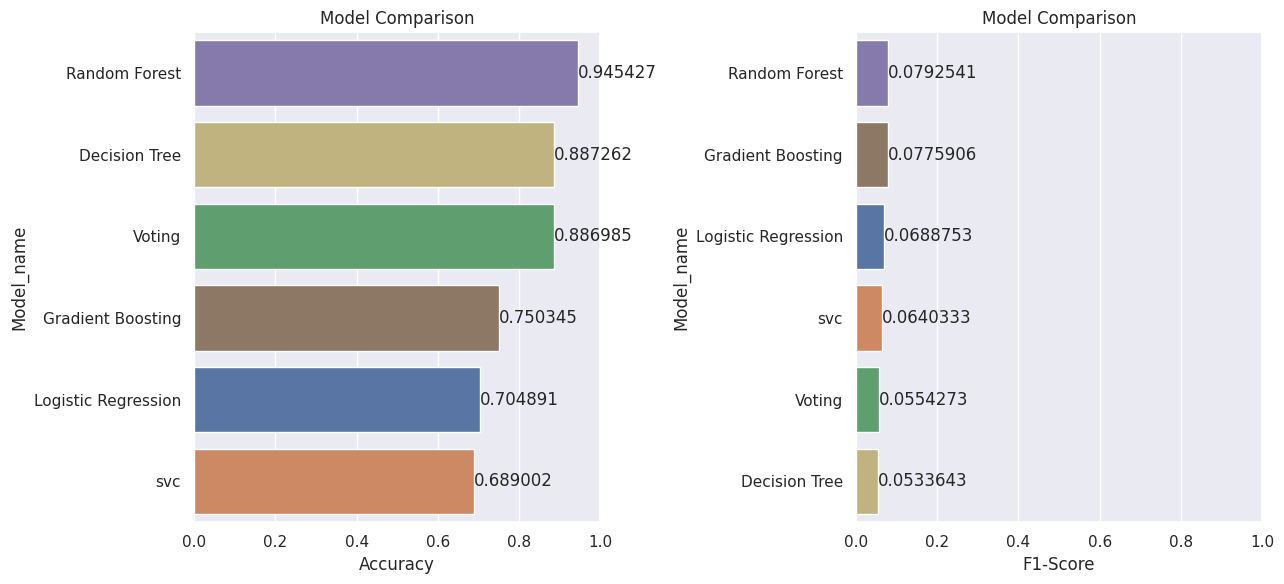

In [36]:

plt.figure(figsize=(13, 6))
custom_palette = {
    "Logistic Regression": "#4c72b0",          # deep blue
    "svc": "#dd8452",          # orange
    "Voting": "#55a868",     # green
    "Random Forest": "#8172b3",     # purple
    "Gradient Boosting": "#937860", # brown
    "Decision Tree": "#ccb974",     # khaki
}


plt.subplot(1,2,1)
ax = sns.barplot(x='Test_acc', y='Model_name',data=result_df.sort_values(by='Test_acc', ascending=False), palette=custom_palette)
for i in ax.containers:
    plt.bar_label(i)
plt.xlabel("Accuracy")
plt.title("Model Comparison")
plt.xlim(0, 1)

plt.subplot(1,2,2)
ax = sns.barplot(x='f1_score', y='Model_name',data=result_df.sort_values(by='f1_score', ascending=False), palette=custom_palette)
for i in ax.containers:
    plt.bar_label(i)
plt.xlabel("F1-Score")
plt.title("Model Comparison")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()


In [37]:
model = RandomForestClassifier(random_state=42,class_weight='balanced')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [35,40,45]
    }

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=2
)

# Fit model
grid_search.fit(x_train_scaled_df, y_train)



Fitting 10 folds for each of 12 candidates, totalling 120 fits


GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10],
                         'min_samples_split': [35, 40, 45],
                         'n_estimators': [100, 200]},
             scoring='recall', verbose=2)

Best Parameters: {'max_depth': 10, 'min_samples_split': 45, 'n_estimators': 100}
Train Accuracy: 94.32 %
Test Accuracy: 86.36 %
F1 Score: 10.03 %
Recall: 69.62 %
Precision: 5.4 %

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.87      0.93      7159
           1       0.05      0.70      0.10        79

    accuracy                           0.86      7238
   macro avg       0.53      0.78      0.51      7238
weighted avg       0.99      0.86      0.92      7238

ROC AUC Score: 0.8983796619639615
Confusion Matrix:


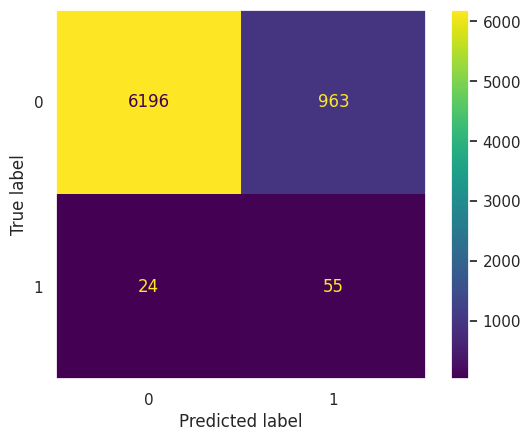

In [38]:
# Best parameters and model
print("Best Parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_

# Predictions
y_pred = best_rf.predict(x_test_scaled_df)
y_proba = best_rf.predict_proba(x_test_scaled_df)[:, 1]

# Evaluation
print('Train Accuracy:',round(grid_search.score(x_train_scaled_df, y_train)*100,2),'%')
print('Test Accuracy:',round(accuracy_score(y_test, y_pred)*100,2),'%')
print('F1 Score:',round(f1_score(y_test, y_pred)*100,2),'%')
print('Recall:',round(recall_score(y_test, y_pred)*100,2),'%')
print('Precision:',round(precision_score(y_test, y_pred)*100,2),'%')


print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", ConfusionMatrixDisplay.from_predictions(y_test, y_pred))
plt.grid('')

### Metrics in fraud detection
Precision and recall are two important evaluation metrics in binary classification tasks like fraud detection, but we are going to prioritize recall over precision in this case.

In the context of fraud detection, missing actual fraudulent transactions (false negatives) can be much more costly and harmful than falsely flagging legitimate transactions as fraud (false positives). A high recall ensures that the model can identify as many actual fraudulent cases as possible, reducing the chances of overlooking fraudulent activities.

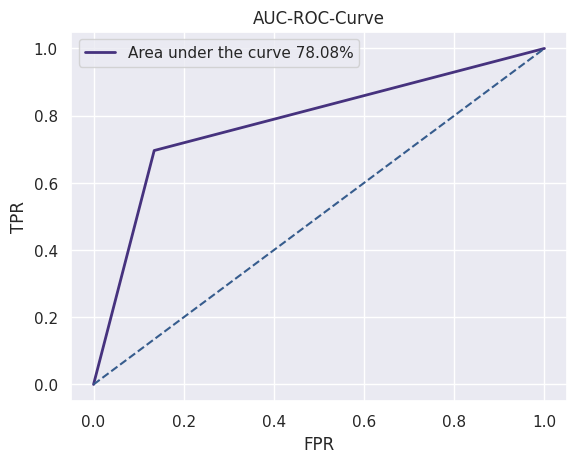

In [39]:
#auc -roc curve
fpr, tpr, thre = roc_curve(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

#plot
plt.plot(fpr, tpr, lw=2, label=f"Area under the curve {round(auc*100,2)}%")
plt.plot([0,1],[0,1],ls='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('AUC-ROC-Curve')
plt.legend()
plt.show()

In [40]:
imp = best_rf.feature_importances_
col_names = x_train_scaled_df.columns

fet_imp = pd.DataFrame({'feature':col_names,'importance':imp})
fet_imp = fet_imp.sort_values(by='importance',ascending=False)
fet_imp['importance(%)'] = 100* fet_imp['importance']/fet_imp['importance'].sum()
fet_imp['cummulative(%)'] = fet_imp['importance(%)'].cumsum()
fet_imp

,feature,importance,importance(%),cummulative(%)
2,paymentMethodAgeDays,0.465523,46.552260,46.552260
3,isWeekend,0.353450,35.345030,81.897290
1,localTime,0.097822,9.782164,91.679454
0,numItems,0.059131,5.913063,97.592517
4,paymentMethod_paypal,0.007173,0.717323,98.309840
5,paymentMethod_storecredit,0.005999,0.599874,98.909714
7,Category_shopping,0.005605,0.560480,99.470195
6,Category_food,0.005298,0.529805,100.000000


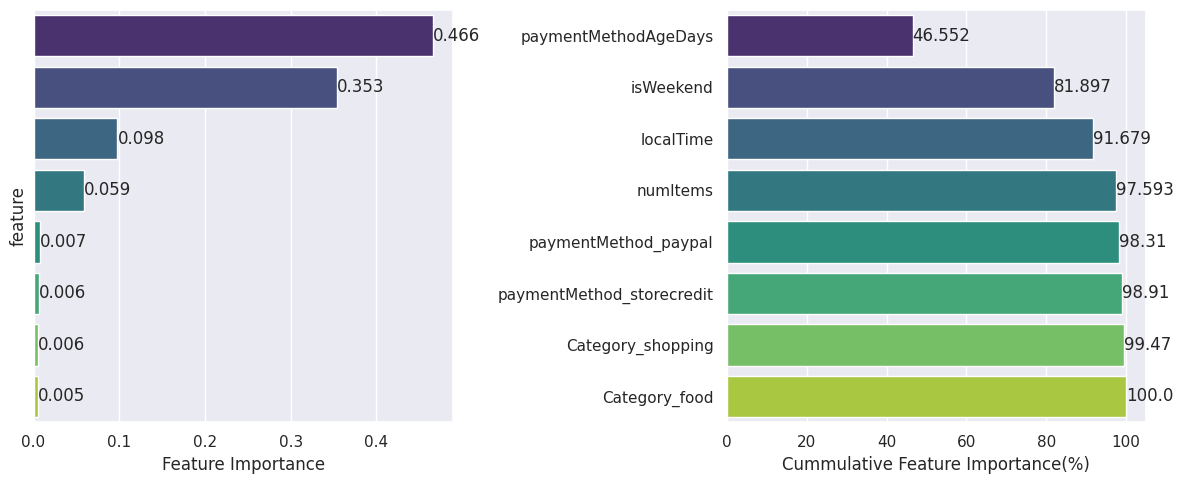

In [41]:
# Plotting Feature Importance
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
ax1=sns.barplot(x='importance', y='feature', data=fet_imp, palette='viridis')
for i in ax1.containers:
    plt.bar_label(i,fmt=lambda x: f'{round(x,3)}')
plt.yticks([])
plt.xlabel('Feature Importance')


plt.subplot(1,2,2)
ax2=sns.barplot(x='cummulative(%)', y='feature', data=fet_imp, palette='viridis')
for i in ax2.containers:
    plt.bar_label(i,fmt=lambda x: f'{round(x,3)}')
plt.ylabel('')
plt.xlabel('Cummulative Feature Importance(%)')

plt.tight_layout()
plt.show()